In [4]:
## FIle Read
import os
import zipfile
import json
import pandas as pd

zip_file = os.path.join("data", "archive.zip")

# Extract zip if it exists
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall("data")
    print("Extracted archive.zip")

# Load the LDJSON file
ldjson_file = os.path.join("data", "marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson")
print(f"Loading {os.path.basename(ldjson_file)}")

Extracted archive.zip
Loading marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson


In [5]:
records = []
with open(ldjson_file, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 33)


,uniq_id,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,...,colour,no__of_reviews,seller_name,seller_id,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books
0,26d41bdc1495de290bc8e6062d927729,2020-02-07 05:11:36 +0000,B07STS2W9T,https://www.amazon.in/Facon-Kalamkari-Handbloc...,LA' Facon Cotton Kalamkari Handblock Saree Blo...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1968255031,LA' Facon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,410c62298852e68f34c35560f2311e5a,2020-02-07 08:45:56 +0000,B07N6TD2WL,https://www.amazon.in/Sf-Jeans-Pantaloons-T-Sh...,Sf Jeans By Pantaloons Men's Plain Slim fit T-...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1968123031,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,52e31bb31680b0ec73de0d781a23cc0a,2020-02-06 11:09:38 +0000,B07WJ6WPN1,https://www.amazon.in/LOVISTA-Traditional-Prin...,LOVISTA Cotton Gota Patti Tassel Traditional P...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1968255031,LOVISTA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25798d6dc43239c118452d1bee0fb088,2020-02-07 08:32:45 +0000,B07PYSF4WZ,https://www.amazon.in/People-Printed-Regular-T...,People Men's Printed Regular fit T-Shirt,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1968123031,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ad8a5a196d515ef09dfdaf082bdc37c4,2020-02-06 14:27:48 +0000,B082KXNM7X,https://www.amazon.in/Monte-Carlo-Cotton-Colla...,Monte Carlo Grey Solid Cotton Blend Polo Colla...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1968070031,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df["weight"].describe()

count        23745.0
mean     999999999.0
std              0.0
min      999999999.0
25%      999999999.0
50%      999999999.0
75%      999999999.0
max      999999999.0
Name: weight, dtype: float64

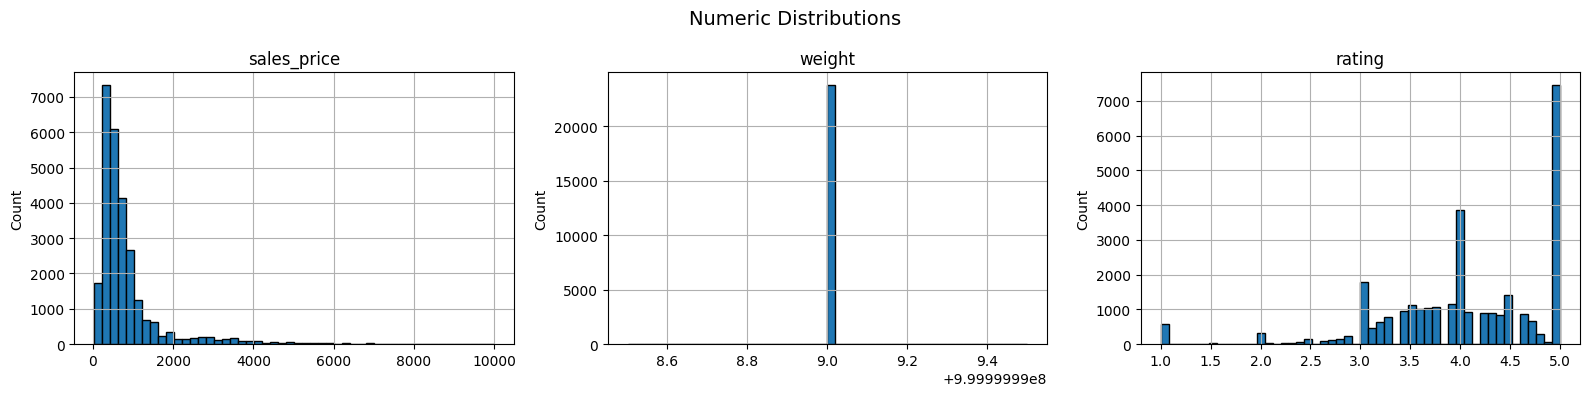

,sales_price,weight,rating
count,27110.000000,23745.0,30000.000000
mean,862.172397,999999999.0,4.039857
std,964.223008,0.0,0.840009
min,39.000000,999999999.0,1.000000
25%,379.000000,999999999.0,3.500000
50%,590.000000,999999999.0,4.000000
75%,899.000000,999999999.0,4.900000
max,9988.000000,999999999.0,5.000000


In [13]:
## Data Distribution Analysis (columns useful for similarity)
import matplotlib.pyplot as plt

# Convert numeric-like columns
for col in ["sales_price", "weight", "rating"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Numeric distributions ---
numeric_cols = ["sales_price", "weight", "rating"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    df[col].dropna().hist(bins=50, ax=ax, edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Count")
plt.suptitle("Numeric Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# --- Numeric summary ---
df[numeric_cols].describe()


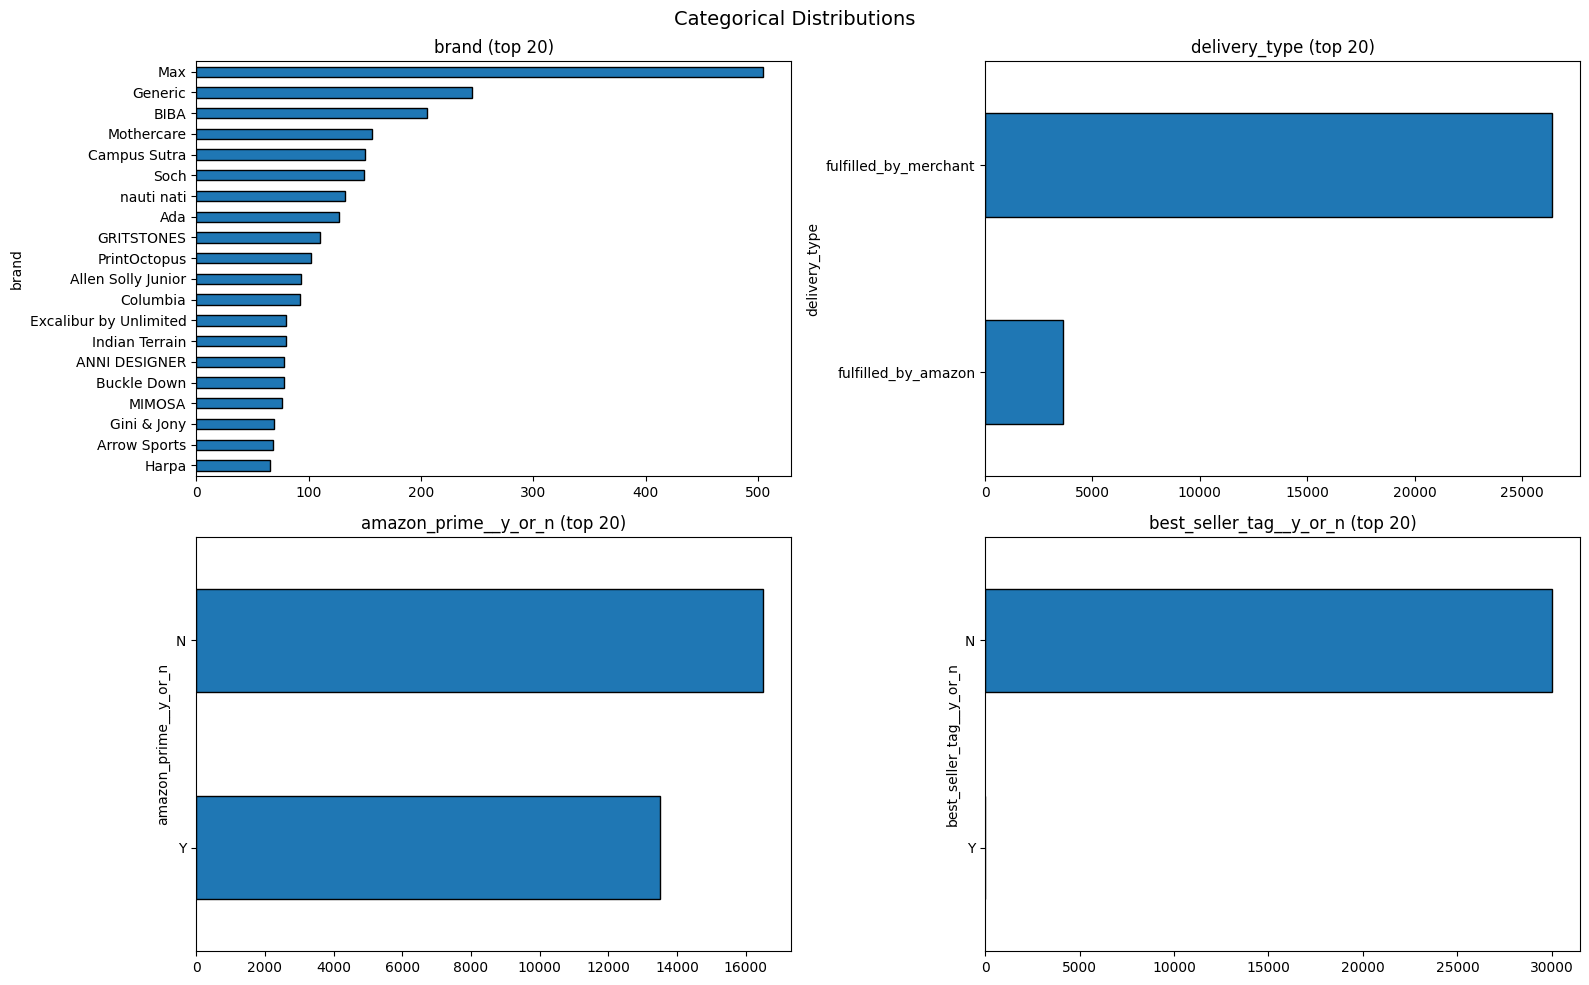

In [15]:
# --- Categorical distributions ---
cat_cols = ["brand", "delivery_type", "amazon_prime__y_or_n", "best_seller_tag__y_or_n"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flat, cat_cols):
    top = df[col].value_counts().head(20)
    top.plot.barh(ax=ax, edgecolor="black")
    ax.set_title(f"{col} (top 20)")
    ax.invert_yaxis()
plt.suptitle("Categorical Distributions", fontsize=14)
plt.tight_layout()
plt.show()


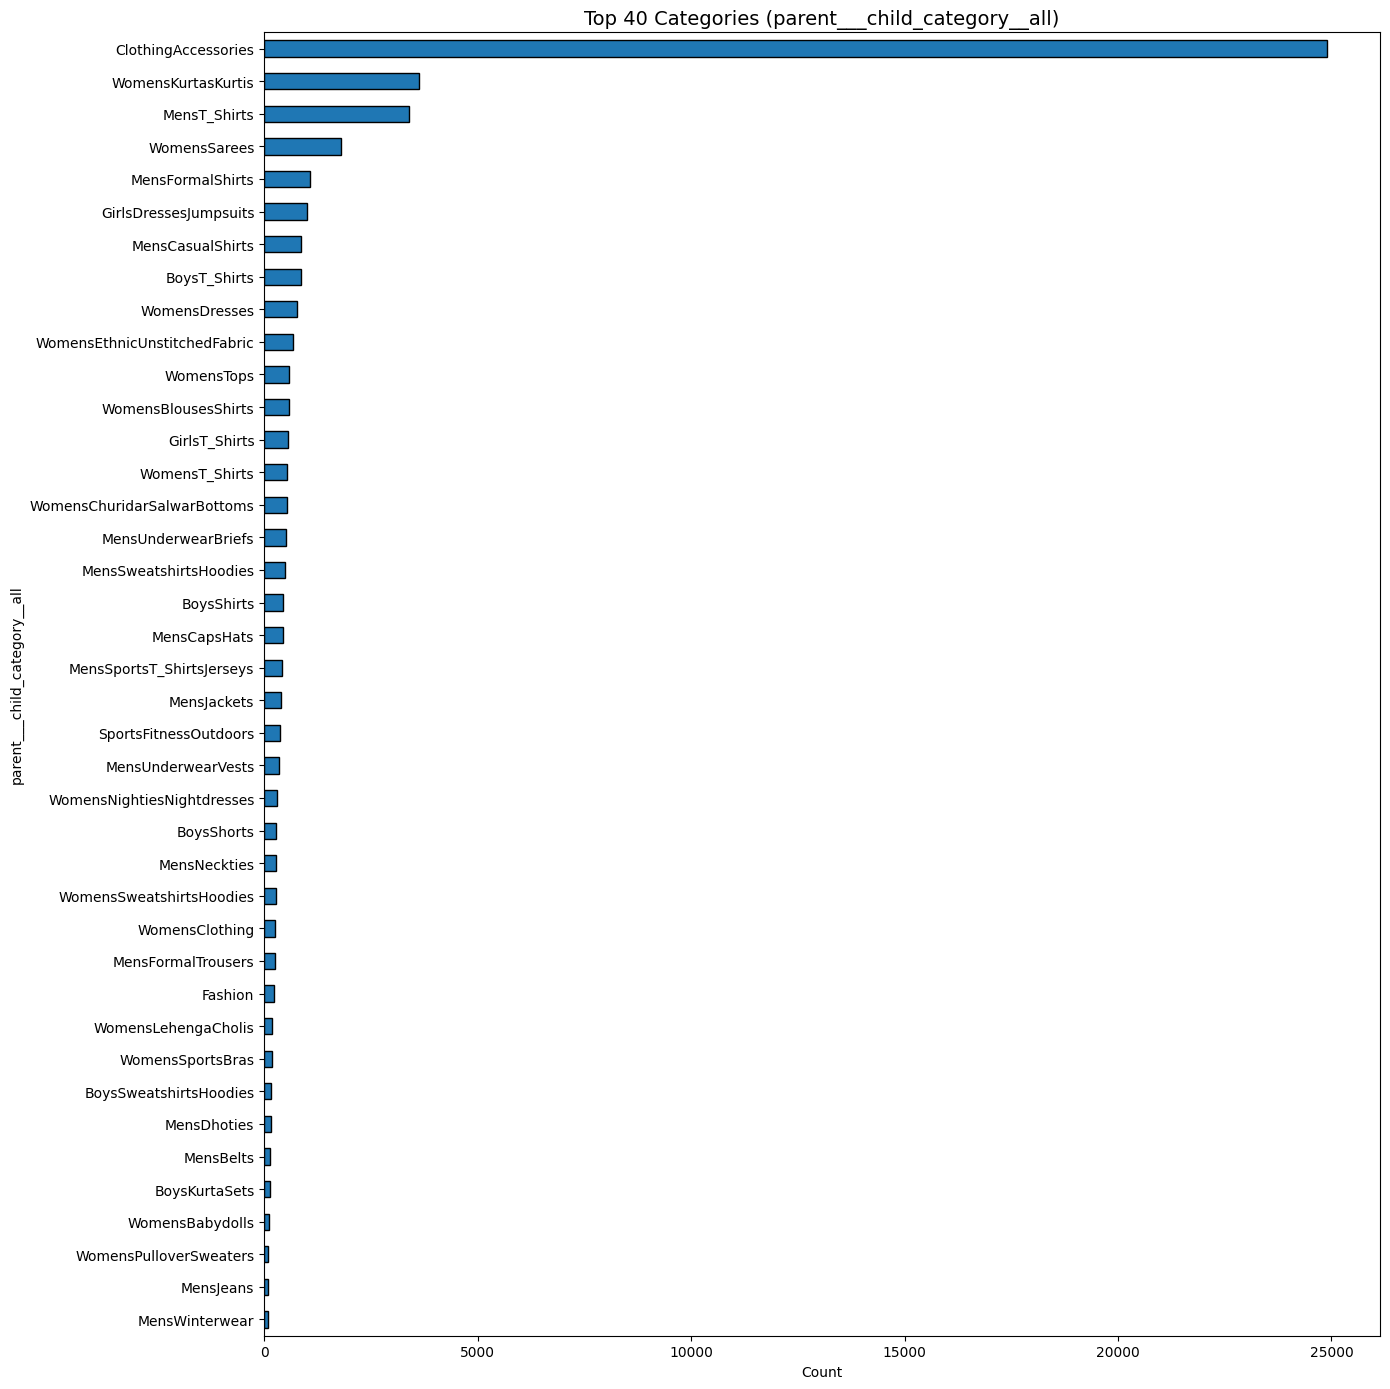

,category,count
0,ClothingAccessories,24893
1,WomensKurtasKurtis,3616
2,MensT_Shirts,3390
3,WomensSarees,1809
4,MensFormalShirts,1075
...,...,...
248,WomensYogaClothing,1
249,GirlsSkirts,1
250,MensGlassesCases,1
251,MensSneakers,1


In [19]:
# --- Category Distribution from parent___child_category__all ---
# Field is a dict: {category_name: rank_string} — extract keys as categories

def extract_categories(val):
    if isinstance(val, dict):
        return list(val.keys())
    if isinstance(val, str) and val.strip():
        return [v.strip() for v in val.split(">")]
    return []

all_cats = df["parent___child_category__all"].dropna().apply(extract_categories).explode()
cat_counts = all_cats[all_cats.notna() & (all_cats != "")].value_counts()

# Table: unique categories with counts
cat_counts_df = cat_counts.reset_index()
cat_counts_df.columns = ["category", "count"]

# Top-40 bar chart
fig, ax = plt.subplots(figsize=(14, 14))
cat_counts.head(40).sort_values().plot.barh(ax=ax, edgecolor="black")
ax.set_title("Top 40 Categories (parent___child_category__all)", fontsize=14)
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

cat_counts_df


In [20]:
## Feature vectors for similarity
# 1. brand
# 2. category (N+1 categories, one-hot encoded), add "others"
# 